In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

# torch.manual_seed(0)
# torch.cuda.manual_seed(0)

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"

sys.path.append(f"{global_path}/SS-HSU_benchmark")
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [13]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

n_xp = 10

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [14]:
dofa, Y_init_dofa, new_H = rsfm.create_fm("DOFA", Y_init, size="base", version="v1", path=global_path)
specaware, Y_init_specaware, _ = rsfm.create_fm("SpecAware", Y_init, size="large", version="v1", path=global_path)
specvit, Y_init_specvit, new_H_specvit = rsfm.create_fm("SpecViT", Y_init, size="base", version="v1", path=global_path)

_, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
_, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)
_, features_specvit = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths)

D = int(features_dofa.shape[0])
alpha_dofa = int(features_dofa.shape[1]**0.5)
alpha_specaware = int(features_specaware.shape[1]**0.5)
alpha_specvit= int(features_specvit.shape[1]**0.5)

print(f"DOFA: {features_dofa.shape}")
print(f"SpecAware: {features_specaware.shape}")
print(f"SpecViT: {features_specvit.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2982.18it/s]


DOFA: torch.Size([768, 196])
SpecAware: torch.Size([768, 784])
SpecViT: torch.Size([768, 1024])


In [24]:
def extract_features(dofa=None, specaware=None, specvit=None, Y=None, wavelengths=None, A=None):
    
    if A != None:
            # Define model spatial sizes and extraction functions
        model_config = {
            'dofa': {'size': 14, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 224, wavelengths, A)},
            'specaware': {'size': 28, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 224, wavelengths, A)},
            'specvit': {'size': 32, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 128, wavelengths, A)}
        }

        # Determine which models are provided
        provided_models = []
        if dofa is not None: provided_models.append('dofa')
        if specaware is not None: provided_models.append('specaware')
        if specvit is not None: provided_models.append('specvit')

        if not provided_models:
            raise ValueError("At least one model must be provided.")

        # Determine target spatial size (max of provided models)
        target_size = max(model_config[m]['size'] for m in provided_models)

        # Extract and upscale features
        features_list = []

        for model_name in provided_models:
            model = locals()[model_name]
            size = model_config[model_name]['size']
            extract_fn = model_config[model_name]['extract_fn']

            # Extract features
            Y_, A_fm, features = extract_fn(model)
            # features = utils.standardise(features)
            # features = utils.normalize(features, is_endmember=True)

            # Upscale if needed
            if size < target_size:
                features_2d = utils.oneD_to_2d(features).unsqueeze(0)
                features_up = F.interpolate(features_2d, size=(target_size, target_size))[0].flatten(1)
            else:
                features_up = features
                Y_fm = Y_

            features_list.append(features_up)

        # Concatenate features
        features = torch.cat(features_list, dim=0)

        return Y_fm, A_fm, features
    
    else:
        # Define model spatial sizes and extraction functions
        model_config = {
            'dofa': {'size': 14, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 224, wavelengths)},
            'specaware': {'size': 28, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 224, wavelengths)},
            'specvit': {'size': 32, 'extract_fn': lambda m: rsfm.extract_f(m, Y, 128, wavelengths)}
        }

        # Determine which models are provided
        provided_models = []
        if dofa is not None: provided_models.append('dofa')
        if specaware is not None: provided_models.append('specaware')
        if specvit is not None: provided_models.append('specvit')

        if not provided_models:
            raise ValueError("At least one model must be provided.")

        # Determine target spatial size (max of provided models)
        target_size = max(model_config[m]['size'] for m in provided_models)

        # Extract and upscale features
        features_list = []

        for model_name in provided_models:
            model = locals()[model_name]
            size = model_config[model_name]['size']
            extract_fn = model_config[model_name]['extract_fn']

            # Extract features
            Y_, features = extract_fn(model)
            # features = utils.standardise(features)
            # features = utils.normalize(features, is_endmember=True)

            # Upscale if needed
            if size < target_size:
                features_2d = utils.oneD_to_2d(features).unsqueeze(0)
                features_up = F.interpolate(features_2d, size=(target_size, target_size))[0].flatten(1)
            else:
                features_up = features
                Y_fm = Y_

            features_list.append(features_up)

        # Concatenate features
        features = torch.cat(features_list, dim=0)

        return Y_fm, features

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.158, NMSE = 0.132
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.159, NMSE = 0.130
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.170, NMSE = 0.131
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.160, NMSE = 0.125
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.171, NMSE = 0.156
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.169, NMSE = 0.134
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.151, NMSE = 0.130

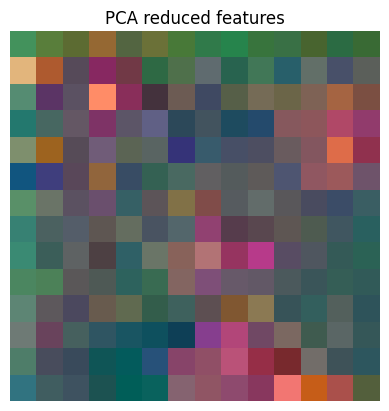

Upsampler has 0.148992M params
Average SAD = 0.164 ± 0.008, MSE = 0.135 ± 0.009


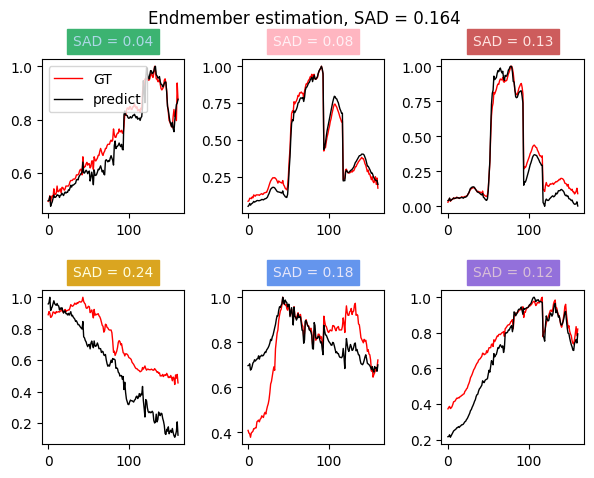

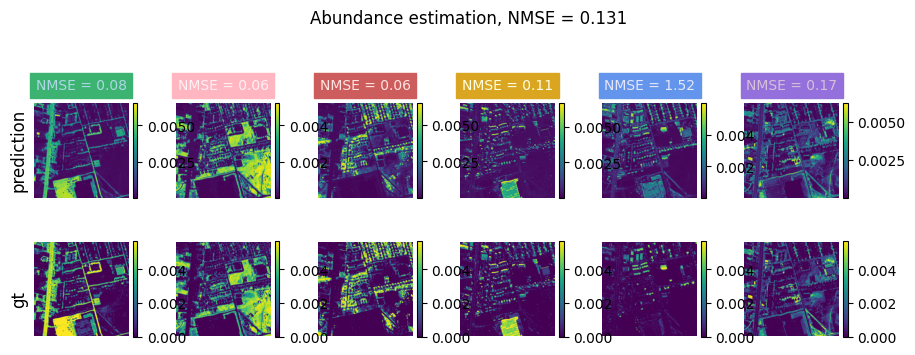

In [27]:
"""All 3 models"""

mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha_dofa, H=new_H, B=B, c=c, upsampler="Features_fusion_grouped", n_features=1)#, channel_selector=True)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_dofa/Y_init_dofa.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = extract_features(dofa=dofa, Y=Y, wavelengths=wavelengths)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, channel_selector=model.channel_selector)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        _, A_init_fm, features = extract_features(dofa=dofa, Y=Y, wavelengths=wavelengths, A=A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

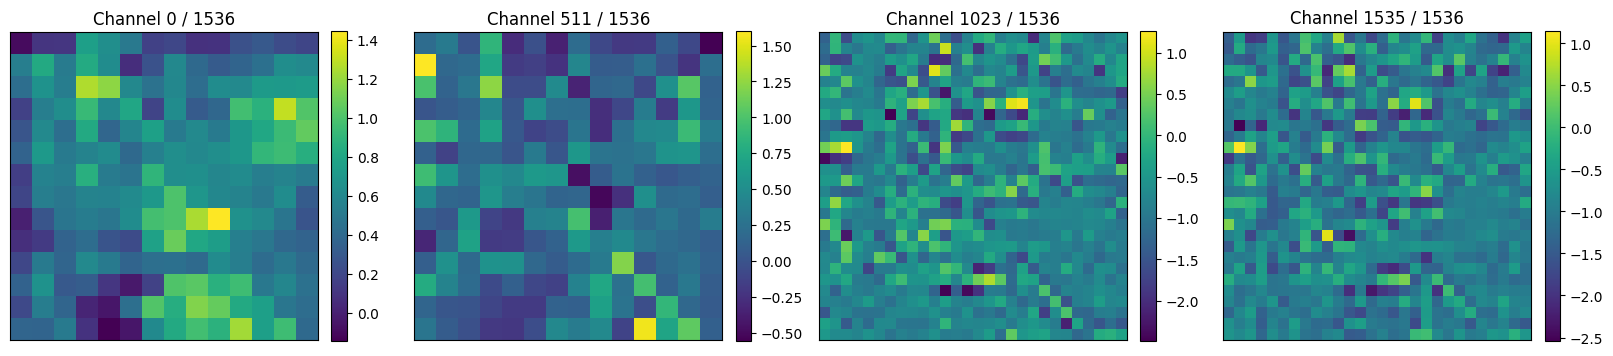

In [20]:
plots.plot_hsi(utils.oneD_to_2d(features))

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.487, NMSE = 0.698
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.092, NMSE = 0.161
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.094, NMSE = 0.160
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.095, NMSE = 0.162
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.091, NMSE = 0.153
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.487, NMSE = 0.595
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.493, NMSE = 0.674

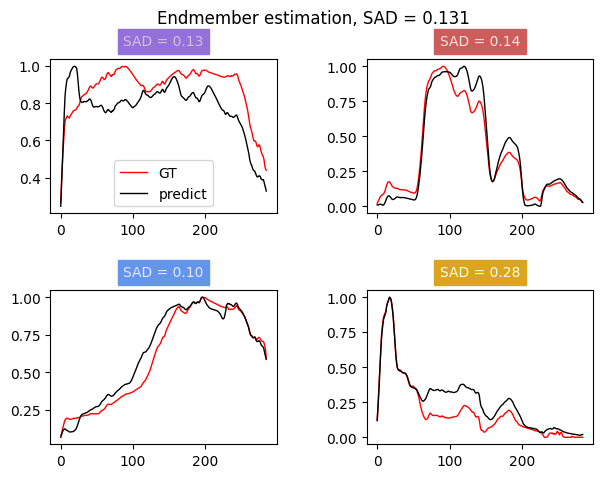

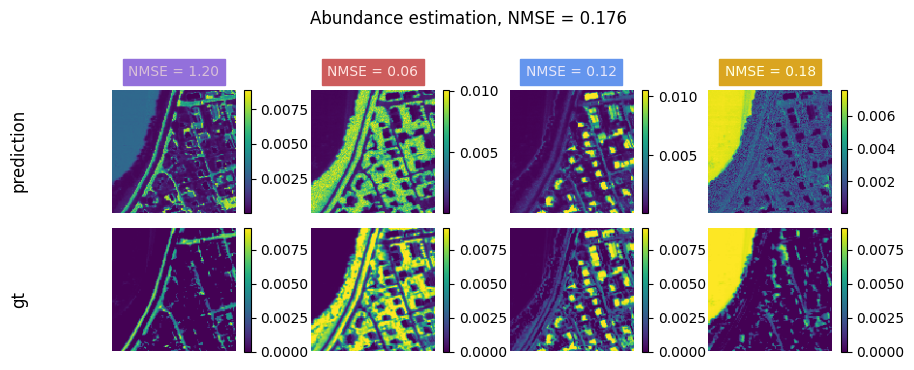

In [34]:
"""SpecViT features"""

mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H_specvit, new_H_specvit)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H_specvit, new_H_specvit)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha_specvit, H=new_H_specvit, B=B, c=c, upsampler="Linear", n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specvit/Y_init_specvit.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(specvit, Y, new_H_specvit, wavelengths)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        _, A_init_fm, features = rsfm.extract_f(specvit, Y, new_H_specvit, wavelengths, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.096, NMSE = 0.170
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.089, NMSE = 0.154
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.095, NMSE = 0.164
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.098, NMSE = 0.160
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.091, NMSE = 0.156
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.479, NMSE = 0.525
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.094, NMSE = 0.168

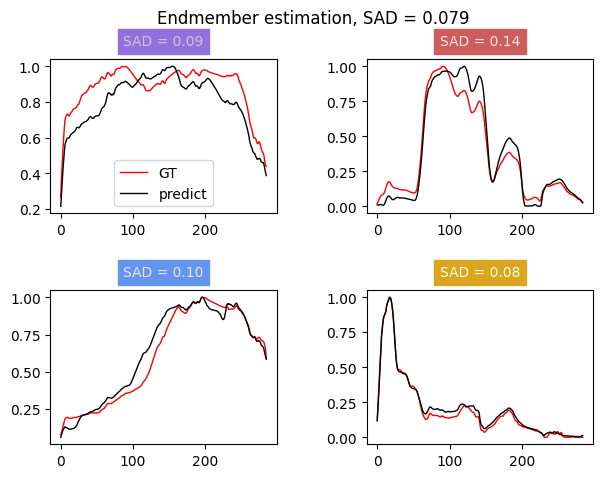

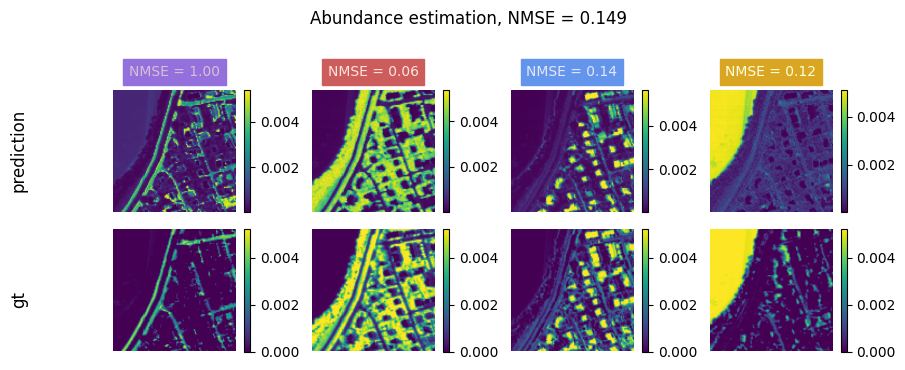

In [15]:
"""SpecAware features"""

mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha_specaware, H=new_H, B=B, c=c, upsampler="Linear", n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specaware/Y_init_specaware.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(specaware, Y, new_H, wavelengths)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        _, A_init_fm, features = rsfm.extract_f(specaware, Y, new_H, wavelengths, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.092, NMSE = 0.137
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.081, NMSE = 0.124
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.087, NMSE = 0.137
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.095, NMSE = 0.134
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.092, NMSE = 0.125
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.093, NMSE = 0.139
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.087, NMSE = 0.133

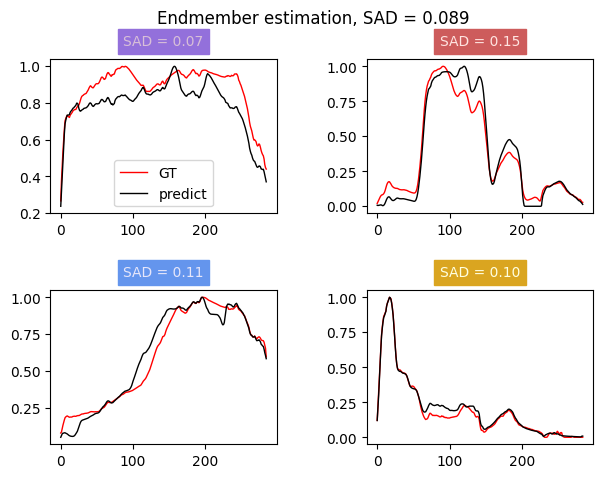

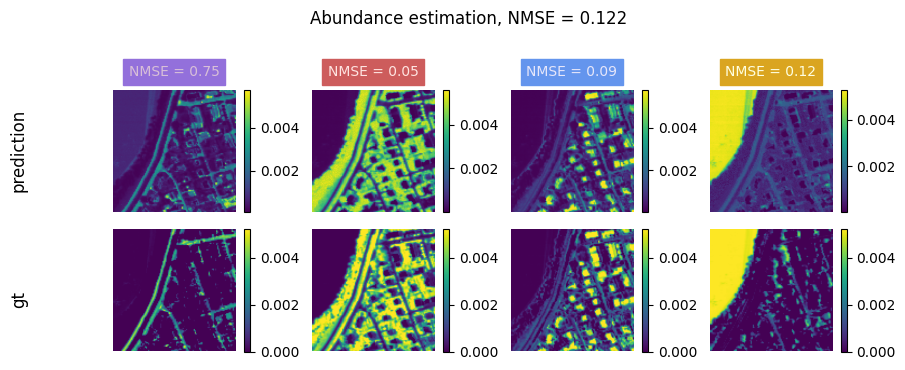

In [14]:
"""DOFA features"""

mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D, alpha=alpha_dofa, H=new_H, B=B, c=c, upsampler="Linear", n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_dofa/Y_init_dofa.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(dofa, Y, new_H, wavelengths)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        _, A_init_fm, features = rsfm.extract_f(dofa, Y, new_H, wavelengths, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")